# Analisis RNN/LSTM Image Captioning pada Flickr8k

Notebook ini menganalisis hasil eksperimen image captioning pada dataset Flickr8k menggunakan decoder SimpleRNN dan LSTM. Seluruh analisis menggunakan artifact eksperimen yang sudah dihasilkan sebelumnya, sehingga fokus notebook ini adalah evaluasi model, interpretasi metrik, dan analisis trade-off antar arsitektur.

Cakupan analisis RNN/LSTM:
- Feature extraction CNN encoder frozen.
- Preprocessing caption dan teacher forcing.
- 12 variasi pre-inject: SimpleRNN dan LSTM, layer recurrent 1/2/3, hidden state 128/512.
- Evaluasi BLEU-4, METEOR, dan waktu inference pada test split.
- Perbandingan Keras vs forward propagation from scratch.
- Pengaruh panjang maksimum caption.
- Analisis kualitatif minimal 10 gambar.
- Bonus: init-inject dan beam search.


## 1. Setup Analisis

Bagian ini menyiapkan library, path artifact, dan helper untuk membaca hasil eksperimen. Notebook tidak melakukan training ulang agar evaluasi yang dibahas konsisten dengan artifact yang tersimpan.

In [259]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
plt.style.use('seaborn-v0_8-whitegrid')

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'artifacts' / 'captioning').exists():
            return candidate
    raise FileNotFoundError('Could not find repo root containing artifacts/captioning')

ROOT = find_repo_root()
ART = ROOT / 'artifacts' / 'captioning'
FAFO = ART / 'fafo'
REPORT_DIR = ART / 'report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

def read_csv(name: str) -> pd.DataFrame:
    path = FAFO / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def read_json(path: Path):
    with path.open(encoding='utf-8') as file:
        return json.load(file)

def pct(value: float) -> str:
    return f'{100 * value:.2f}%'

def savefig(name: str) -> Path:
    path = REPORT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    return path

ROOT, ART, FAFO, REPORT_DIR


(WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML'),
 WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning'),
 WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/fafo'),
 WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report'))

## 2. Ketersediaan Artifact Eksperimen

Sebelum analisis dilakukan, artifact utama dicek terlebih dahulu untuk memastikan evaluasi berasal dari hasil eksperimen yang lengkap: evaluasi pre-inject, perbandingan Keras vs scratch, eksperimen panjang caption, contoh kualitatif, dan eksperimen bonus.

In [260]:
required_files = {
    'preinject_eval': FAFO / 'test_evaluation_full_images.csv',
    'initinject_eval': FAFO / 'initinject_test_evaluation_full_images.csv',
    'rnn_keras_vs_scratch': FAFO / 'rnn_layers2_hidden128_test_keras_vs_scratch_500_images.csv',
    'lstm_keras_vs_scratch': FAFO / 'lstm_layers1_hidden128_test_keras_vs_scratch_500_images.csv',
    'rnn_max_caption': FAFO / 'rnn_layers2_hidden128_test_max_caption_length_1000_images.csv',
    'lstm_max_caption': FAFO / 'lstm_layers1_hidden128_test_max_caption_length_1000_images.csv',
    'comparison_examples_csv': FAFO / 'comparison_20_examples.csv',
    'comparison_examples_png': FAFO / 'comparison_20_examples.png',
    'preinject_summary': ART / 'experiments' / 'decoder_training_summary.json',
    'initinject_summary': ART / 'experiments' / 'initinject_decoder_training_summary.json',
    'feature_metadata': ART / 'features' / 'inception_v3_flickr8k_metadata.json',
    'preprocess_metadata': ART / 'preprocessed' / 'caption_preprocessing_metadata.json',
}
manifest = pd.DataFrame(
    [{'artifact': key, 'exists': path.exists(), 'path': str(path.relative_to(ROOT))} for key, path in required_files.items()]
)
manifest


,artifact,exists,path
0,preinject_eval,True,artifacts\captioning\fafo\test_evaluation_full_images.csv
1,initinject_eval,True,artifacts\captioning\fafo\initinject_test_evaluation_full_images.csv
2,rnn_keras_vs_scratch,True,artifacts\captioning\fafo\rnn_layers2_hidden128_test_keras_vs_scratch_500_images.csv
3,lstm_keras_vs_scratch,True,artifacts\captioning\fafo\lstm_layers1_hidden128_test_keras_vs_scratch_500_images.csv
4,rnn_max_caption,True,artifacts\captioning\fafo\rnn_layers2_hidden128_test_max_caption_length_1000_images.csv
5,lstm_max_caption,True,artifacts\captioning\fafo\lstm_layers1_hidden128_test_max_caption_length_1000_images.csv
6,comparison_examples_csv,True,artifacts\captioning\fafo\comparison_20_examples.csv
7,comparison_examples_png,True,artifacts\captioning\fafo\comparison_20_examples.png
8,preinject_summary,True,artifacts\captioning\experiments\decoder_training_summary.json
9,initinject_summary,True,artifacts\captioning\experiments\initinject_decoder_training_summary.json


## 3. Ringkasan Dataset, Feature Extraction, dan Preprocessing

Bagian ini menjelaskan data dan representasi input yang digunakan oleh decoder. Ringkasan ini penting karena kualitas caption tidak hanya ditentukan oleh arsitektur RNN/LSTM, tetapi juga oleh feature CNN, vocabulary, padding, dan skema teacher forcing.

In [261]:
feature_meta = read_json(required_files['feature_metadata'])
preprocess_meta = read_json(required_files['preprocess_metadata'])
teacher_meta = read_json(ART / 'teacher_forcing' / 'teacher_forcing_metadata.json')

summary_rows = [
    ('CNN encoder', feature_meta.get('encoder_name', 'InceptionV3')),
    ('Feature artifact shape', feature_meta.get('features_shape', feature_meta.get('feature_shape'))),
    ('Feature dimension per image', feature_meta.get('feature_dim', 2048)),
    ('Vocabulary size', preprocess_meta.get('vocab_size')),
    ('Max training caption length', preprocess_meta.get('max_seq_len_train', preprocess_meta.get('max_sequence_length'))),
    ('Decoder timesteps', teacher_meta.get('decoder_timesteps')),
    ('Train caption rows', teacher_meta.get('split_shapes', {}).get('train', {}).get('feature_indices', [None])[0]),
    ('Validation caption rows', teacher_meta.get('split_shapes', {}).get('val', {}).get('feature_indices', [None])[0]),
    ('Test caption rows', teacher_meta.get('split_shapes', {}).get('test', {}).get('feature_indices', [None])[0]),
]
pd.DataFrame(summary_rows, columns=['Item', 'Value'])


,Item,Value
0,CNN encoder,InceptionV3
1,Feature artifact shape,"[8091, 2048]"
2,Feature dimension per image,2048
3,Vocabulary size,7426
4,Max training caption length,38
5,Decoder timesteps,37
6,Train caption rows,30000
7,Validation caption rows,5000
8,Test caption rows,5000


### Interpretasi Dataset dan Preprocessing

Pipeline RNN/LSTM memakai InceptionV3 pretrained sebagai encoder visual frozen, sehingga decoder tidak perlu mempelajari representasi gambar dari nol. Feature vector `(2048,)` per gambar disimpan sekali dan dipakai ulang untuk semua variasi decoder, membuat perbandingan RNN vs LSTM lebih adil karena input visualnya identik. Vocabulary dibangun dari caption train saja untuk menghindari leakage dari validation/test, sedangkan token `<unk>` menangani kata di luar vocabulary saat evaluasi.

Teacher forcing mengubah setiap caption menjadi pasangan input-target yang bergeser satu timestep. Dengan `max_seq_len_train = 38`, decoder belajar memprediksi token berikutnya untuk 37 timestep output. Setup ini sesuai spesifikasi pre-inject Show and Tell: feature CNN diproyeksikan sebagai timestep awal sebelum token caption.


## 4. Arsitektur yang Dievaluasi

Arsitektur utama mengikuti pre-inject: feature vector CNN InceptionV3 diproyeksikan ke `embed_dim`, lalu ditempatkan sebagai timestep pertama sebelum embedding token caption. Hidden state awal SimpleRNN adalah nol; hidden state dan cell state awal LSTM juga nol. Training memakai teacher forcing dengan target sequence yang digeser satu posisi.

In [262]:
pre_summary = pd.DataFrame(read_json(required_files['preinject_summary']))
init_summary = pd.DataFrame(read_json(required_files['initinject_summary']))
pre_summary['injection_method'] = 'pre-inject'
configs = pd.concat([pre_summary, init_summary], ignore_index=True)
configs[['experiment_id', 'injection_method', 'model_kind', 'recurrent_layers', 'hidden_units', 'epochs', 'batch_size', 'final_loss', 'final_val_loss', 'elapsed_seconds']]


,experiment_id,injection_method,model_kind,recurrent_layers,hidden_units,epochs,batch_size,final_loss,final_val_loss,elapsed_seconds
0,rnn_layers1_hidden128,pre-inject,rnn,1,128,20,64,2.301701,3.491946,191.167742
1,rnn_layers1_hidden512,pre-inject,rnn,1,512,20,64,1.571669,3.815494,261.557987
2,rnn_layers2_hidden128,pre-inject,rnn,2,128,20,64,2.251466,3.516951,248.174275
3,rnn_layers2_hidden512,pre-inject,rnn,2,512,20,64,1.830593,3.733288,352.225325
4,rnn_layers3_hidden128,pre-inject,rnn,3,128,20,64,2.350126,3.543905,306.951381
5,rnn_layers3_hidden512,pre-inject,rnn,3,512,20,64,2.229913,3.648489,467.719170
6,lstm_layers1_hidden128,pre-inject,lstm,1,128,20,64,2.428833,3.387200,237.663334
7,lstm_layers1_hidden512,pre-inject,lstm,1,512,20,64,1.820681,3.586949,322.811803
8,lstm_layers2_hidden128,pre-inject,lstm,2,128,20,64,2.576121,3.401433,229.997307
9,lstm_layers2_hidden512,pre-inject,lstm,2,512,20,64,1.997326,3.469095,372.891128


## 5. Evaluasi Utama: 12 Variasi Pre-Inject

Evaluasi utama membandingkan 12 konfigurasi decoder pre-inject pada split test Flickr8k. Setiap konfigurasi dievaluasi menggunakan BLEU-4, METEOR, dan waktu inference per gambar agar performa dapat dilihat dari sisi kualitas caption dan efisiensi.

In [263]:
pre_eval = read_csv('test_evaluation_full_images.csv')
pre_eval['model'] = pre_eval['model_kind'].str.upper()
pre_eval_sorted = pre_eval.sort_values(['bleu4', 'meteor'], ascending=False).reset_index(drop=True)
pre_eval_sorted.insert(0, 'rank_bleu4', np.arange(1, len(pre_eval_sorted) + 1))
pre_eval_sorted[['rank_bleu4', 'experiment_id', 'model', 'recurrent_layers', 'hidden_units', 'images', 'bleu4', 'meteor', 'seconds_per_image']]


,rank_bleu4,experiment_id,model,recurrent_layers,hidden_units,images,bleu4,meteor,seconds_per_image
0,1,lstm_layers1_hidden128,LSTM,1,128,1000,0.122957,0.322081,0.024476
1,2,rnn_layers3_hidden128,RNN,3,128,1000,0.114533,0.316314,0.018194
2,3,rnn_layers2_hidden128,RNN,2,128,1000,0.114181,0.327470,0.020506
3,4,rnn_layers3_hidden512,RNN,3,512,1000,0.113789,0.320883,0.022503
4,5,rnn_layers2_hidden512,RNN,2,512,1000,0.111525,0.310792,0.013562
5,6,lstm_layers2_hidden128,LSTM,2,128,1000,0.110781,0.320847,0.013961
6,7,lstm_layers2_hidden512,LSTM,2,512,1000,0.109788,0.321058,0.021433
7,8,lstm_layers3_hidden512,LSTM,3,512,1000,0.109349,0.311399,0.017163
8,9,rnn_layers1_hidden128,RNN,1,128,1000,0.108479,0.308107,0.025289
9,10,lstm_layers1_hidden512,LSTM,1,512,1000,0.105557,0.315834,0.015371


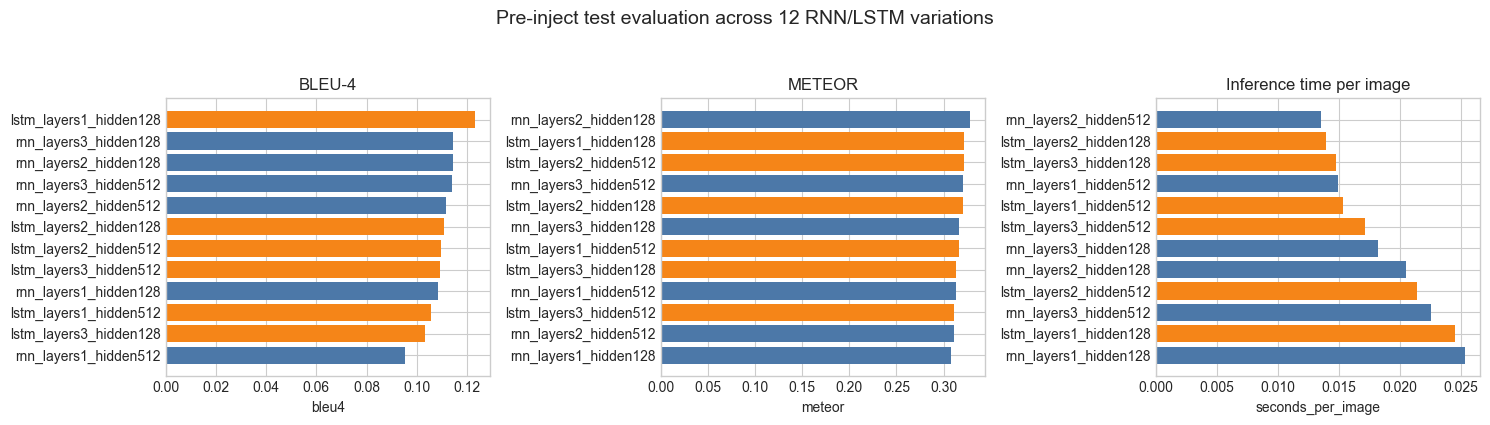

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/preinject_12_variation_metrics.png')

In [264]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'RNN': '#4C78A8', 'LSTM': '#F58518'}
for ax, metric, title in zip(axes, ['bleu4', 'meteor', 'seconds_per_image'], ['BLEU-4', 'METEOR', 'Inference time per image']):
    ordered = pre_eval.sort_values(metric, ascending=(metric == 'seconds_per_image'))
    ax.barh(ordered['experiment_id'], ordered[metric], color=[colors[m] for m in ordered['model']])
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.invert_yaxis()
fig.suptitle('Pre-inject test evaluation across 12 RNN/LSTM variations', y=1.05, fontsize=14)
path = savefig('preinject_12_variation_metrics.png')
plt.show()
path


### Interpretasi Evaluasi Utama Pre-Inject

Dari 12 variasi pre-inject, model dengan BLEU-4 tertinggi adalah `lstm_layers1_hidden128` dengan BLEU-4 `0.1230`, METEOR `0.3221`, dan waktu inference `0.0245` detik/gambar. Model dengan METEOR tertinggi adalah `rnn_layers2_hidden128` dengan METEOR `0.3275`, BLEU-4 `0.1142`, dan waktu `0.0205` detik/gambar. Ini menunjukkan bahwa pemilihan model terbaik bergantung pada prioritas metrik: BLEU-4 lebih mengutamakan kecocokan n-gram panjang, sementara METEOR lebih toleran terhadap variasi bentuk kata dan overlap unigram.

Secara rata-rata, LSTM sedikit unggul dari RNN pada pre-inject (`BLEU-4 0.1103` vs `0.1096`, `METEOR 0.3174` vs `0.3160`) dan sedikit lebih cepat pada rata-rata waktu artifact ini (`0.0179` vs `0.0192` detik/gambar). Selisihnya kecil, sehingga kesimpulan utama sebaiknya tidak hanya menyatakan LSTM dominan, tetapi bahwa LSTM terbaik unggul pada BLEU-4 sementara RNN tertentu tetap kompetitif, terutama pada METEOR dan trade-off waktu.


## 6. Pengaruh Jumlah Layer dan Hidden State

Bagian ini menghasilkan grafik : perbandingan jumlah layer untuk RNN, jumlah layer untuk LSTM, hidden state untuk RNN, dan hidden state untuk LSTM.

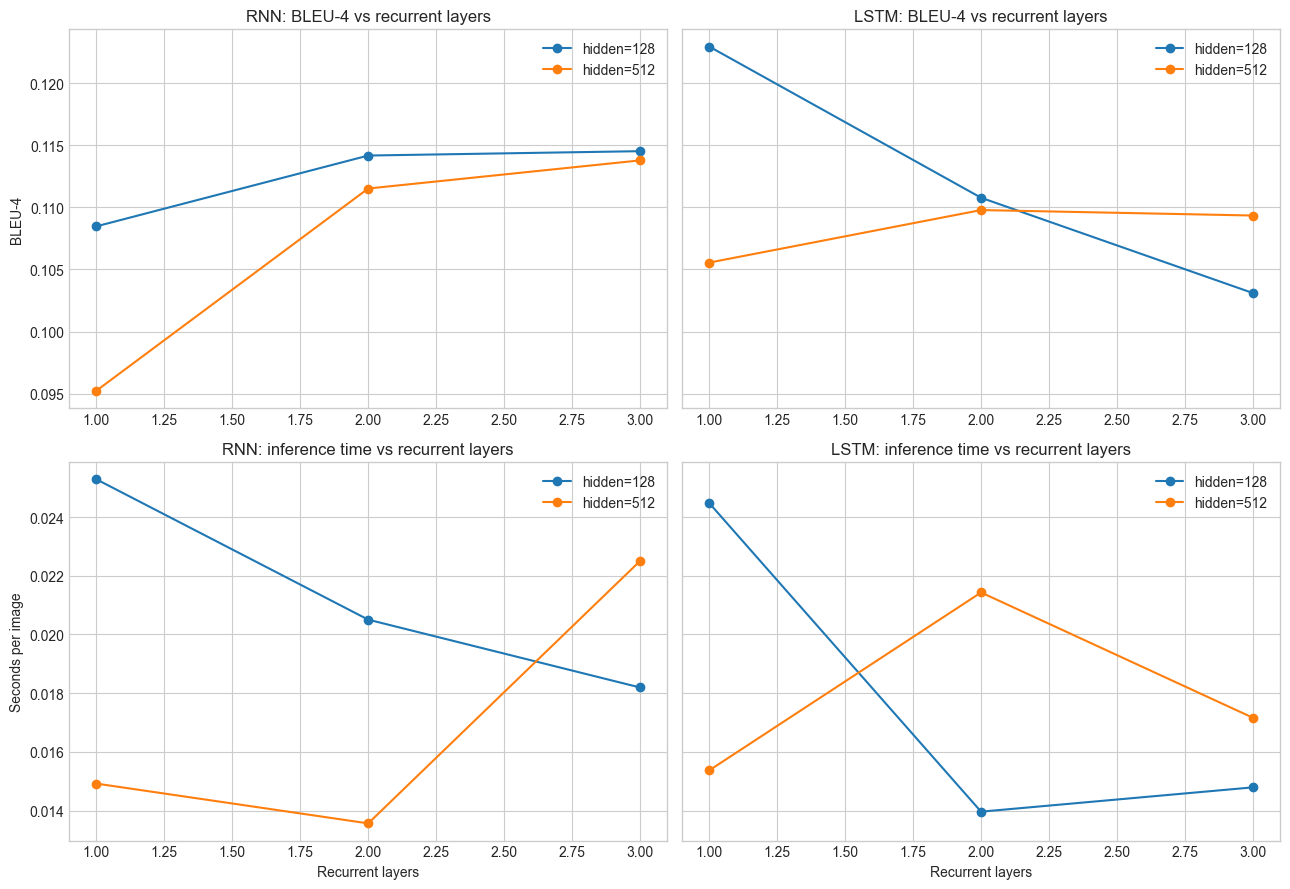

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/layer_hidden_effects_preinject.png')

In [265]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey='row')

for col, model in enumerate(['RNN', 'LSTM']):
    subset = pre_eval[pre_eval['model'] == model]
    for hidden, group in subset.groupby('hidden_units'):
        group = group.sort_values('recurrent_layers')
        axes[0, col].plot(group['recurrent_layers'], group['bleu4'], marker='o', label=f'hidden={hidden}')
        axes[1, col].plot(group['recurrent_layers'], group['seconds_per_image'], marker='o', label=f'hidden={hidden}')
    axes[0, col].set_title(f'{model}: BLEU-4 vs recurrent layers')
    axes[1, col].set_title(f'{model}: inference time vs recurrent layers')
    axes[1, col].set_xlabel('Recurrent layers')
    axes[0, col].legend()
    axes[1, col].legend()
axes[0, 0].set_ylabel('BLEU-4')
axes[1, 0].set_ylabel('Seconds per image')
path = savefig('layer_hidden_effects_preinject.png')
plt.show()
path


In [266]:
pivot_metrics = pre_eval.pivot_table(
    index=['model', 'recurrent_layers'],
    columns='hidden_units',
    values=['bleu4', 'meteor', 'seconds_per_image'],
)
pivot_metrics.round(4)


bleu4          meteor         seconds_per_image  \
hidden_units               128     512     128     512               128   
model recurrent_layers                                                     
LSTM  1                 0.1230  0.1056  0.3221  0.3158            0.0245   
      2                 0.1108  0.1098  0.3208  0.3211            0.0140   
      3                 0.1031  0.1093  0.3131  0.3114            0.0148   
RNN   1                 0.1085  0.0952  0.3081  0.3127            0.0253   
      2                 0.1142  0.1115  0.3275  0.3108            0.0205   
      3                 0.1145  0.1138  0.3163  0.3209            0.0182   

                                
hidden_units               512  
model recurrent_layers          
LSTM  1                 0.0154  
      2                 0.0214  
      3                 0.0172  
RNN   1                 0.0149  
      2                 0.0136  
      3                 0.0225

### Interpretasi Jumlah Layer dan Hidden State

Untuk pre-inject RNN, konfigurasi hidden `128` lebih stabil daripada hidden `512`: RNN 512 cenderung memiliki training loss lebih rendah tetapi tidak menghasilkan BLEU-4 terbaik, indikasi kapasitas tambahan tidak selalu berubah menjadi generalisasi yang lebih baik. Pada RNN hidden 128, penambahan layer dari 1 ke 2/3 menaikkan BLEU-4 dari sekitar `0.1085` ke `0.1142-0.1145`, tetapi peningkatannya kecil setelah layer kedua.

Untuk LSTM, konfigurasi terbaik justru `1` layer dan `128` hidden unit. Menambah layer atau hidden unit tidak meningkatkan BLEU-4 pada test split. Ini masuk akal untuk Flickr8k: dataset relatif kecil dan caption relatif pendek, sehingga model yang terlalu besar lebih mudah overfit atau menghasilkan probabilitas token yang tidak lebih baik saat greedy decoding.


## 7. Training dan Validation Loss

Grafik loss dipakai untuk menjelaskan stabilitas training, overfitting, dan perbedaan perilaku model kecil/besar.

In [267]:
def load_history(experiment_id: str) -> pd.DataFrame:
    path = ART / 'histories' / f'{experiment_id}_history.json'
    data = read_json(path)
    hist = pd.DataFrame(data['history'])
    hist['epoch'] = np.arange(1, len(hist) + 1)
    hist['experiment_id'] = experiment_id
    hist['model_kind'] = data['config']['model_kind']
    hist['recurrent_layers'] = data['config']['recurrent_layers']
    hist['hidden_units'] = data['config']['hidden_units']
    return hist

histories = pd.concat([load_history(exp) for exp in pre_eval['experiment_id']], ignore_index=True)
histories.head()


,loss,val_loss,epoch,experiment_id,model_kind,recurrent_layers,hidden_units
0,5.169693,4.593678,1,lstm_layers1_hidden128,lstm,1,128
1,4.203667,4.127789,2,lstm_layers1_hidden128,lstm,1,128
2,3.851425,3.921187,3,lstm_layers1_hidden128,lstm,1,128
3,3.645316,3.774832,4,lstm_layers1_hidden128,lstm,1,128
4,3.476494,3.655293,5,lstm_layers1_hidden128,lstm,1,128


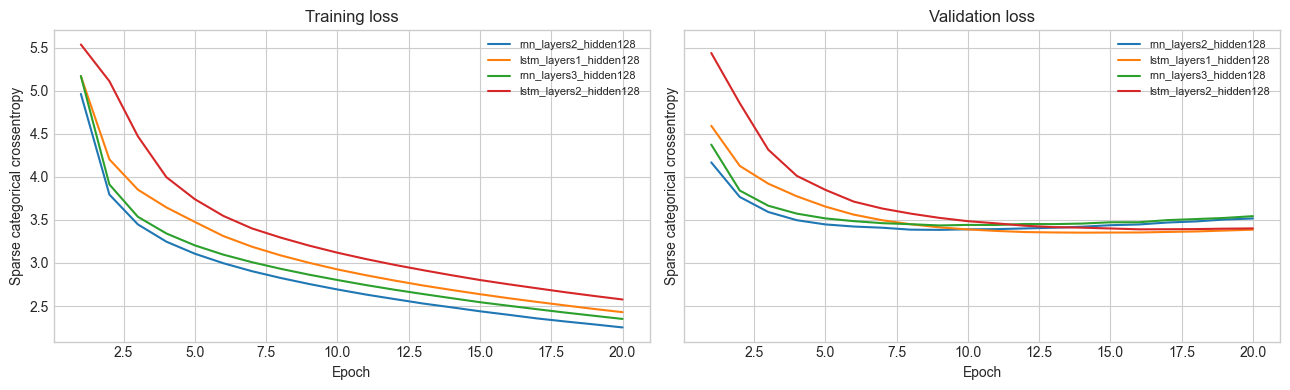

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/selected_training_validation_loss.png')

In [268]:
selected_ids = ['rnn_layers2_hidden128', 'lstm_layers1_hidden128', 'rnn_layers3_hidden128', 'lstm_layers2_hidden128']
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for experiment_id in selected_ids:
    hist = histories[histories['experiment_id'] == experiment_id]
    axes[0].plot(hist['epoch'], hist['loss'], label=experiment_id)
    axes[1].plot(hist['epoch'], hist['val_loss'], label=experiment_id)
axes[0].set_title('Training loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Sparse categorical crossentropy')
    ax.legend(fontsize=8)
path = savefig('selected_training_validation_loss.png')
plt.show()
path


In [269]:
best_by_model = pre_eval.sort_values('bleu4', ascending=False).groupby('model').head(1)
best_by_model[['model', 'experiment_id', 'recurrent_layers', 'hidden_units', 'bleu4', 'meteor', 'seconds_per_image']]


,model,experiment_id,recurrent_layers,hidden_units,bleu4,meteor,seconds_per_image
0,LSTM,lstm_layers1_hidden128,1,128,0.122957,0.322081,0.024476
7,RNN,rnn_layers3_hidden128,3,128,0.114533,0.316314,0.018194


### Interpretasi Training dan Validation Loss

Kurva loss menunjukkan training loss terus turun hampir monoton, sementara validation loss cenderung melandai lalu naik pada beberapa model. Pola ini menunjukkan mulai terjadinya overfitting setelah epoch tertentu: model makin baik menghafal caption train, tetapi performa generalisasi tidak ikut membaik. Hal ini terutama terlihat pada model hidden `512`, yang memiliki kapasitas lebih besar dan training loss lebih rendah, tetapi tidak selalu memperoleh BLEU-4/METEOR lebih tinggi.

Kurva ini menunjukkan bahwa pemilihan model tidak cukup hanya berdasarkan training loss. Model dengan validation loss lebih stabil dan gap train-validation lebih kecil lebih layak dipilih karena menunjukkan generalisasi yang lebih baik. Early stopping atau regularisasi tambahan dapat menjadi saran pengembangan.


## 8. Perbandingan RNN vs LSTM

Analisis utama dapat memakai dua sudut pandang: model terbaik per keluarga dan rata-rata performa seluruh variasi.

In [270]:
family_summary = pre_eval.groupby('model').agg(
    mean_bleu4=('bleu4', 'mean'),
    best_bleu4=('bleu4', 'max'),
    mean_meteor=('meteor', 'mean'),
    best_meteor=('meteor', 'max'),
    mean_seconds_per_image=('seconds_per_image', 'mean'),
).reset_index()
family_summary.round(4)


,model,mean_bleu4,best_bleu4,mean_meteor,best_meteor,mean_seconds_per_image
0,LSTM,0.1103,0.1230,0.3174,0.3221,0.0179
1,RNN,0.1096,0.1145,0.3160,0.3275,0.0192


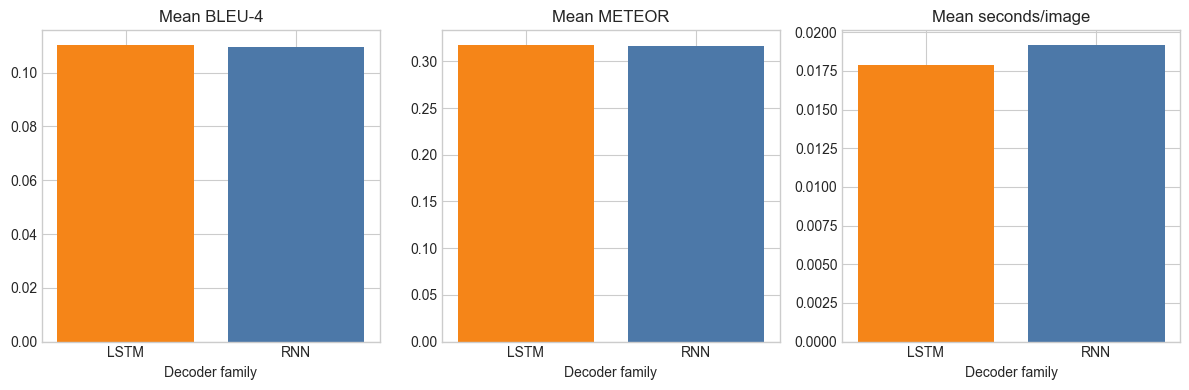

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/rnn_vs_lstm_family_summary.png')

In [271]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, metric, title in zip(axes, ['mean_bleu4', 'mean_meteor', 'mean_seconds_per_image'], ['Mean BLEU-4', 'Mean METEOR', 'Mean seconds/image']):
    ax.bar(family_summary['model'], family_summary[metric], color=[colors[m] for m in family_summary['model']])
    ax.set_title(title)
    ax.set_xlabel('Decoder family')
path = savefig('rnn_vs_lstm_family_summary.png')
plt.show()
path


### Interpretasi RNN vs LSTM

Secara teori, LSTM lebih tahan terhadap vanishing gradient karena memiliki input gate, forget gate, output gate, dan cell state yang membantu mempertahankan informasi jangka panjang. Hasil eksperimen mendukung sebagian teori ini: LSTM terbaik memberi BLEU-4 tertinggi pada konfigurasi utama pre-inject. Namun RNN tetap kompetitif karena caption Flickr8k relatif pendek dan banyak pola caption berupa frasa visual sederhana seperti subjek-aksi-objek.

Perbandingan ini sebaiknya ditulis sebagai trade-off, bukan klaim mutlak. LSTM unggul pada model terbaik berbasis BLEU-4, sedangkan RNN `rnn_layers2_hidden128` memberikan METEOR terbaik pada pre-inject dan waktu inference yang lebih rendah dibanding LSTM terbaik BLEU-4. Jadi, jika prioritasnya kualitas n-gram, pilih LSTM; jika prioritasnya METEOR dan efisiensi, RNN terpilih masih masuk akal.


## 9. Keras vs From Scratch: Score dan Execution Time

Bagian ini membandingkan decoder Keras dengan implementasi forward propagation NumPy scratch pada model RNN dan LSTM terpilih. CSV yang tersedia berisi per-image caption, score, dan timing untuk 500 gambar test. Exact sentence match digunakan sebagai validasi kesetaraan forward propagation, sedangkan `seconds_per_image` dipakai sebagai metrik execution time inference.

Catatan environment: implementasi scratch memakai NumPy sehingga berjalan di CPU. Keras/TensorFlow juga berjalan di CPU pada environment ini karena TensorFlow native Windows tidak mendeteksi GPU, tetapi tetap memakai kernel TensorFlow yang lebih teroptimasi daripada loop NumPy scratch.

In [272]:
def summarize_keras_scratch(path: Path, model_label: str) -> dict[str, object]:
    df = pd.read_csv(path)
    return {
        'model': model_label,
        'images': len(df),
        'exact_matches': int(df['match'].sum()),
        'match_rate': df['match'].mean(),
        'keras_bleu4': df['keras_bleu4'].mean(),
        'scratch_bleu4': df['scratch_bleu4'].mean(),
        'keras_meteor': df['keras_meteor'].mean(),
        'scratch_meteor': df['scratch_meteor'].mean(),
        'keras_seconds_per_image': df['keras_seconds_per_image'].iloc[0],
        'scratch_seconds_per_image': df['scratch_seconds_per_image'].iloc[0],
        'keras_inference_seconds': df['keras_inference_seconds'].iloc[0],
        'scratch_inference_seconds': df['scratch_inference_seconds'].iloc[0],
    }

scratch_summary = pd.DataFrame([
    summarize_keras_scratch(required_files['rnn_keras_vs_scratch'], 'RNN rnn_layers2_hidden128'),
    summarize_keras_scratch(required_files['lstm_keras_vs_scratch'], 'LSTM lstm_layers1_hidden128'),
])
scratch_summary.round(4)


,model,images,exact_matches,match_rate,keras_bleu4,scratch_bleu4,keras_meteor,scratch_meteor,keras_seconds_per_image,scratch_seconds_per_image,keras_inference_seconds,scratch_inference_seconds
0,RNN rnn_layers2_hidden128,500,500,1.0,0.1250,0.1250,0.3375,0.3375,0.0315,0.0652,15.7612,32.6226
1,LSTM lstm_layers1_hidden128,500,500,1.0,0.1291,0.1291,0.3283,0.3283,0.0293,0.0769,14.6265,38.4441


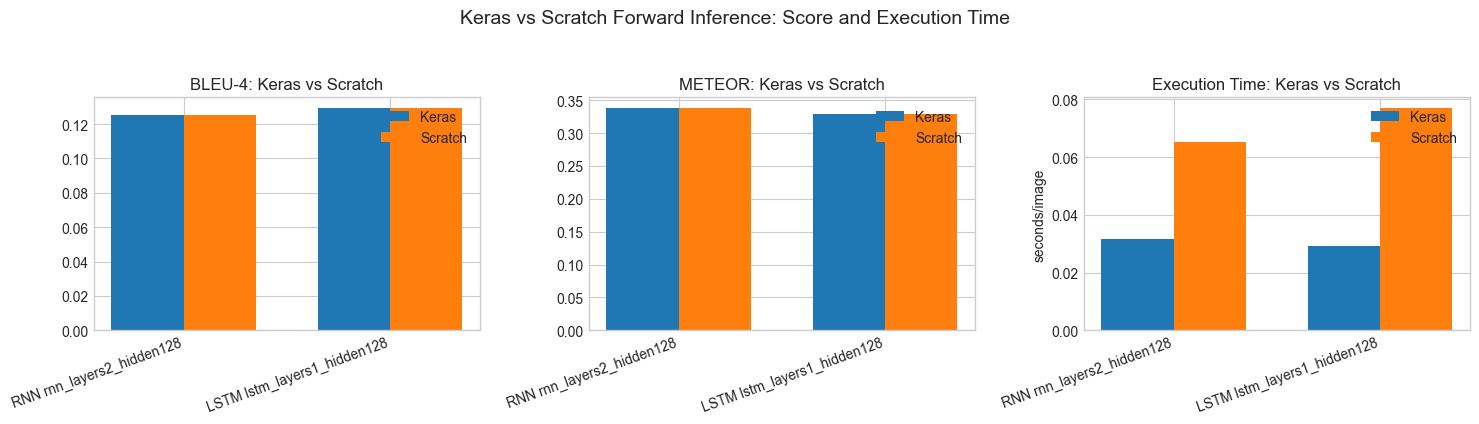

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/keras_vs_scratch_scores_and_time.png')

In [273]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(scratch_summary))
width = 0.35
axes[0].bar(x - width/2, scratch_summary['keras_bleu4'], width, label='Keras')
axes[0].bar(x + width/2, scratch_summary['scratch_bleu4'], width, label='Scratch')
axes[0].set_title('BLEU-4: Keras vs Scratch')
axes[1].bar(x - width/2, scratch_summary['keras_meteor'], width, label='Keras')
axes[1].bar(x + width/2, scratch_summary['scratch_meteor'], width, label='Scratch')
axes[1].set_title('METEOR: Keras vs Scratch')
axes[2].bar(x - width/2, scratch_summary['keras_seconds_per_image'], width, label='Keras')
axes[2].bar(x + width/2, scratch_summary['scratch_seconds_per_image'], width, label='Scratch')
axes[2].set_title('Execution Time: Keras vs Scratch')
axes[2].set_ylabel('seconds/image')
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(scratch_summary['model'], rotation=20, ha='right')
    ax.legend()
fig.suptitle('Keras vs Scratch Forward Inference: Score and Execution Time', y=1.05, fontsize=14)
path = savefig('keras_vs_scratch_scores_and_time.png')
plt.show()
path


### Interpretasi Keras vs From Scratch

Perbandingan Keras vs NumPy scratch menunjukkan exact sentence match `100%` untuk kedua model terpilih pada 500 gambar test. RNN menghasilkan rata-rata BLEU-4 Keras/Scratch `0.1250/0.1250`, sedangkan LSTM `0.1291/0.1291`. Selisih score nol pada artifact terbaru, sehingga implementasi forward propagation scratch dapat dianggap konsisten dengan model Keras.

Dari sisi waktu pada 500 gambar test, Keras lebih cepat daripada implementasi NumPy scratch: RNN Keras/Scratch `0.0315/0.0652` detik per gambar, sedangkan LSTM Keras/Scratch `0.0293/0.0769` detik per gambar. Perbedaan ini wajar karena Keras/TensorFlow memakai operasi tensor yang lebih teroptimasi dan batching yang lebih efisien, sedangkan scratch NumPy memprioritaskan transparansi forward propagation.

Perbedaan waktu ini wajar karena Keras/TensorFlow memakai operasi tensor yang lebih teroptimasi dan batching yang lebih efisien, sedangkan implementasi scratch memakai NumPy CPU dengan loop eksplisit agar alur forward propagation lebih transparan. Jadi, hasil utama dari perbandingan ini adalah validasi correctness: scratch menghasilkan prediksi dan metrik yang sama dengan Keras, tetapi dengan waktu eksekusi lebih lambat karena tidak memakai optimasi backend deep learning.
Poin penting yang perlu masuk:
- Timing hanya untuk decoder inference, bukan raw image ke caption penuh.
- Feature CNN sudah precomputed.
- Keras dan scratch sama-sama CPU di environment ini.
- Keras lebih cepat karena backend optimized, bukan karena modelnya beda.
- Scratch ditujukan untuk transparansi/correctness, bukan speed.

## 10. Pengaruh Panjang Maksimum Caption

Eksperimen ini menjalankan greedy decoding dengan beberapa batas maksimum timestep dan membandingkan BLEU-4.

In [274]:
max_len = pd.concat([
    read_csv('rnn_layers2_hidden128_test_max_caption_length_1000_images.csv'),
    read_csv('lstm_layers1_hidden128_test_max_caption_length_1000_images.csv'),
], ignore_index=True)
max_len['model'] = np.where(max_len['experiment_id'].str.startswith('rnn'), 'RNN', 'LSTM')
max_len[['model', 'experiment_id', 'max_generated_steps', 'images', 'bleu4', 'meteor', 'seconds_per_image']]


,model,experiment_id,max_generated_steps,images,bleu4,meteor,seconds_per_image
0,RNN,rnn_layers2_hidden128,15,1000,0.115009,0.326666,0.025422
1,RNN,rnn_layers2_hidden128,20,1000,0.114179,0.327275,0.014352
2,RNN,rnn_layers2_hidden128,30,1000,0.114186,0.327387,0.019785
3,RNN,rnn_layers2_hidden128,37,1000,0.114181,0.327470,0.020450
4,LSTM,lstm_layers1_hidden128,15,1000,0.125160,0.322801,0.016318
5,LSTM,lstm_layers1_hidden128,20,1000,0.123338,0.322252,0.016628
6,LSTM,lstm_layers1_hidden128,30,1000,0.123036,0.322091,0.023019
7,LSTM,lstm_layers1_hidden128,37,1000,0.122957,0.322081,0.028183


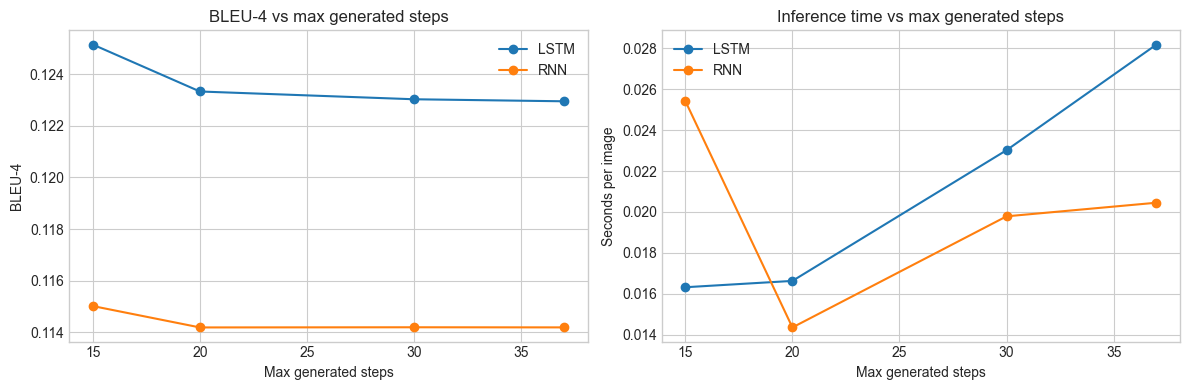

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/max_caption_length_effect.png')

In [275]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model, group in max_len.groupby('model'):
    group = group.sort_values('max_generated_steps')
    axes[0].plot(group['max_generated_steps'], group['bleu4'], marker='o', label=model)
    axes[1].plot(group['max_generated_steps'], group['seconds_per_image'], marker='o', label=model)
axes[0].set_title('BLEU-4 vs max generated steps')
axes[1].set_title('Inference time vs max generated steps')
for ax in axes:
    ax.set_xlabel('Max generated steps')
    ax.legend()
axes[0].set_ylabel('BLEU-4')
axes[1].set_ylabel('Seconds per image')
path = savefig('max_caption_length_effect.png')
plt.show()
path


### Interpretasi Panjang Maksimum Caption

Pada LSTM terpilih, batas `15` timestep memberi BLEU-4 tertinggi (`0.1252`) dibanding `20`, `30`, dan `37`. Pada RNN terpilih, batas `15` juga sedikit lebih baik (`0.1150`) dibanding batas lebih panjang. Artinya, memberi ruang caption lebih panjang tidak otomatis memperbaiki kualitas berdasarkan BLEU-4.

Penyebab utamanya adalah BLEU-4 menghukum token tambahan yang tidak cocok dengan ground truth. Batas yang terlalu panjang memberi decoder kesempatan menghasilkan kata generik atau repetitif setelah inti caption selesai. 

Berdasarkan hasil eksperimen, panjang maksimum caption tidak sebaiknya ditentukan hanya dengan mengikuti caption terpanjang pada data training. Walaupun data training memiliki caption dengan panjang hingga 37 token, hasil evaluasi menunjukkan bahwa batas yang lebih pendek, yaitu 15 timestep, justru menghasilkan BLEU-4 terbaik pada model LSTM maupun RNN. Hal ini menunjukkan bahwa max_caption_length berperan sebagai hyperparameter decoding yang memengaruhi kualitas output akhir model.

Jika batas caption terlalu panjang, decoder memiliki ruang lebih besar untuk menghasilkan token tambahan setelah informasi utama pada gambar sudah tersampaikan. Token tambahan tersebut sering kali bersifat generik, kurang relevan, atau repetitif, sehingga dapat menurunkan skor BLEU-4 karena tidak cocok dengan ground truth. Sebaliknya, batas yang lebih pendek dapat membantu model berhenti lebih awal dan menghasilkan caption yang lebih ringkas serta lebih dekat dengan pola caption referensi.

Dengan demikian, pemilihan max_caption_length perlu dilakukan melalui eksperimen dan evaluasi, bukan hanya berdasarkan panjang maksimum caption pada dataset. Dalam kasus ini, batas 15 timestep menjadi pilihan yang lebih optimal karena mampu menjaga caption tetap padat, mengurangi risiko token tambahan yang tidak relevan, dan menghasilkan skor BLEU-4 tertinggi dibandingkan batas yang lebih panjang.


## 11. Qualitative Comparison Analysis: High, Medium, Low Examples

Bagian ini menampilkan contoh caption RNN, caption LSTM, ground truth, dan score

In [276]:
examples = read_csv('comparison_20_examples.csv')
examples.groupby('quality_bucket').agg(
    examples=('image_id', 'count'),
    mean_rnn_bleu4=('rnn_bleu4', 'mean'),
    mean_lstm_bleu4=('lstm_bleu4', 'mean'),
    mean_rnn_meteor=('rnn_meteor', 'mean'),
    mean_lstm_meteor=('lstm_meteor', 'mean'),
).round(4)


,examples,mean_rnn_bleu4,mean_lstm_bleu4,mean_rnn_meteor,mean_lstm_meteor
quality_bucket,,,,,
high,7,0.7850,0.7640,0.7171,0.7030
low,6,0.0157,0.0069,0.1109,0.0804
medium,7,0.0696,0.0836,0.3688,0.3212


In [277]:
display_cols = ['quality_bucket', 'image_id', 'rnn_prediction', 'lstm_prediction', 'rnn_bleu4', 'lstm_bleu4', 'ground_truths']
examples[display_cols].head(15)


,quality_bucket,image_id,rnn_prediction,lstm_prediction,rnn_bleu4,lstm_bleu4,ground_truths
0,high,426920445_d07d1fd0f7.jpg,a black and white dog is running through the grass,a white dog is running through the grass,1.000000,0.869442,A black and white dog runs on soft green grass . | A dog runs in a field with its tongue sticking out . | A dog runs on a filed with its mouth open . | The ...
1,high,408233586_f2c1be3ce1.jpg,a dog is running through the water,a dog is running through the water,0.866878,0.866878,A brown and black dog fetching a tennis ball in a lake . | A dog in water with its head cocked to the side looking at a ball . | A dog is running through th...
2,high,69189650_6687da7280.jpg,a brown dog is running through the snow,a dog is running through the grass,0.840896,0.740083,A brown dog is running through a brown field . | A brown dog is running through the field . | A brown dog with a collar runs in the dead grass with his tong...
3,high,406642021_9ec852eccf.jpg,a man is climbing a rock wall,a man is climbing a rock wall,0.731110,0.731110,A climber wearing a red shirt is climbing a rock face on a snowy day . | A man in a red shirt climbing a rock with his bare hands . | A man is climbing over...
4,high,421932359_edbf181f44.jpg,a black and white dog is running through the snow,a black and white dog is running through the grass,0.707107,0.725980,A black and white dog is running towards the viewer . | A brown and white dog is running across a brown field . | A dog running through a field towards a ca...
5,high,456512643_0aac2fa9ce.jpg,a brown dog is running through the snow,a brown dog is running through the grass,0.680375,0.707107,a brown dog is running through a grassy field . | A brown dog running through grass . | A dog runs in a grassy field . | A golden-brown dog running through ...
6,high,445655284_c29e6d7323.jpg,a black dog is running through the water,a brown dog is running through the water,0.668740,0.707107,"A black and brown dog walks through the snow near a building . | A black dog , running in the snow . | A black dog running in the snow by some trees . | A l..."
7,medium,505955292_026f1489f2.jpg,a boy in a red jacket is sitting on a red slide,a young boy in a blue shirt is jumping into a pool,0.053864,0.100252,A boy rides a horse . | A young boy rides a brown horse bareback . | Child with purple shirt and bluejeans is atop a brown horse . | The kid is getting onto...
8,medium,772403830_08b72c7da9.jpg,a man in a yellow shirt is surfing,a man in a blue shirt is standing in the water,0.034666,0.119220,A boy wearing black shorts is jumping into the ocean . | A child in swimming trunks jumping into the ocean . | A child jumps over ocean waves at a beach . |...
9,medium,640053014_549d2f23d2.jpg,a man in a yellow shirt and blue helmet is riding a bike on a dirt road,a man in a red shirt is riding a motorcycle on a track,0.052682,0.100697,A cyclist on a neon yellow bike is airborne . | A motorcyclist is attempting a jump with another motorcyclist nearby as well as onlookers . | A person in a ...


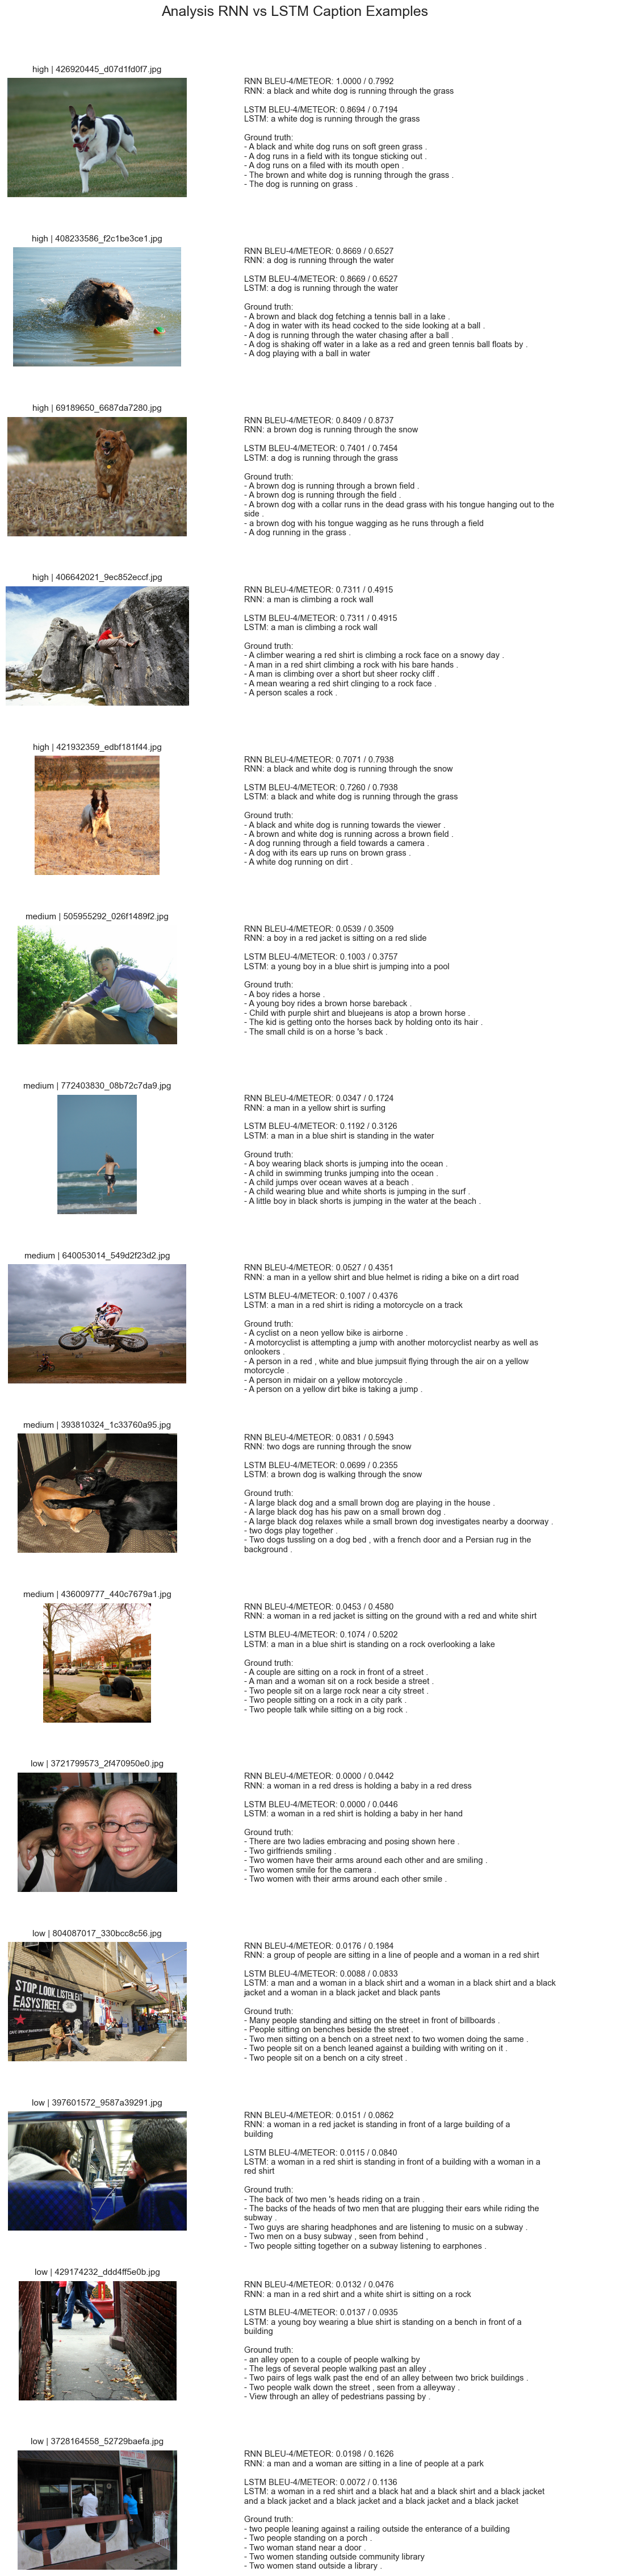

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/comparison_analysis_examples_readable.png')

In [278]:
import textwrap

image_dir = ROOT / 'data' / 'raw' / 'flickr8k' / 'Images'
selected_examples = (
    examples.groupby('quality_bucket', group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    len(selected_examples),
    2,
    figsize=(15, 3.4 * len(selected_examples)),
    gridspec_kw={'width_ratios': [1.15, 1.85]},
)
fig.suptitle('Analysis RNN vs LSTM Caption Examples', fontsize=18, y=0.995)

for row_idx, row in selected_examples.iterrows():
    image_ax, text_ax = axes[row_idx]
    image_path = image_dir / row['image_id']
    if image_path.exists():
        image_ax.imshow(plt.imread(image_path))
    else:
        image_ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
    image_ax.set_title(f"{row['quality_bucket']} | {row['image_id']}", fontsize=11, pad=8)
    image_ax.axis('off')

    ground_truths = str(row['ground_truths']).split(' | ')
    text_lines = [
        f"RNN BLEU-4/METEOR: {row['rnn_bleu4']:.4f} / {row['rnn_meteor']:.4f}",
        *textwrap.wrap(f"RNN: {row['rnn_prediction']}", width=82),
        '',
        f"LSTM BLEU-4/METEOR: {row['lstm_bleu4']:.4f} / {row['lstm_meteor']:.4f}",
        *textwrap.wrap(f"LSTM: {row['lstm_prediction']}", width=82),
        '',
        'Ground truth:',
    ]
    for caption in ground_truths:
        text_lines.extend(textwrap.wrap(f"- {caption}", width=86))

    text_ax.text(0.0, 1.0, '\n'.join(text_lines), ha='left', va='top', fontsize=10.5, linespacing=1.22)
    text_ax.axis('off')

plt.subplots_adjust(top=0.97, hspace=0.42, wspace=0.08)
path = REPORT_DIR / 'comparison_analysis_examples_readable.png'
fig.savefig(path, dpi=180, bbox_inches='tight')
plt.show()
path


### Interpretasi Kualitatif

Contoh high-score umumnya berisi objek dan aksi umum yang sering muncul di Flickr8k, misalnya anjing berlari, orang memanjat, atau aktivitas olahraga. Pada kasus seperti ini, RNN dan LSTM sering menghasilkan struktur caption yang mirip dengan ground truth walaupun detail kecil seperti warna atau latar dapat berbeda.

Contoh medium dan low-score menunjukkan pola error yang lebih informatif: model sering mengganti objek utama dengan objek visual yang umum, salah menebak lokasi seperti grass/snow/water, atau menghasilkan caption generik tentang orang/anjing. LSTM kadang menghasilkan caption lebih panjang dan deskriptif, tetapi panjang tambahan dapat memperbesar risiko detail salah. RNN cenderung lebih pendek/generik pada beberapa kasus. Pola ini dapat digunakan sebagai bahan analisis bahwa BLEU/METEOR tidak hanya mengukur kelancaran bahasa, tetapi juga kecocokan detail visual terhadap ground truth.

#### 1. Contoh Hasil Caption Berdasarkan Kategori Skor

| Kategori | Deskripsi Gambar | Caption RNN | Caption LSTM | Ground Truth Ringkas | Analisis |
|---|---|---|---|---|---|
| High | Seekor anjing hitam-putih berlari di rumput | A black and white dog is running through the grass. | A white dog running through the grass. | Anjing hitam-putih berlari di rumput. | Kedua model berhasil mengenali objek utama, aksi, dan konteks. RNN sedikit lebih lengkap karena menyebut warna hitam-putih. Skor tinggi terjadi karena caption sangat dekat dengan ground truth. |
| High | Seekor anjing berenang atau berlari di air | A dog is running through the water. | Dog is running through the water. | Anjing bergerak di air/danau. | Objek dan aksi utama sesuai. Walaupun detail seperti warna dan danau tidak lengkap, caption tetap cocok secara semantik. |
| High | Anjing cokelat berlari di area rumput/lapangan | A brown dog is running through the snow. | Dog is running through the grass. | Anjing berlari di lapangan/rumput. | LSTM lebih tepat pada konteks tempat, sedangkan RNN salah mengenali latar sebagai salju. Namun keduanya tetap mengenali objek dan aksi utama. |
| High | Seseorang memanjat batu | A man is climbing a rock wall. | A man is climbing a rock wall. | Seorang pria memanjat batu/tebing. | Kedua model menghasilkan caption yang sama dan sangat sesuai. Gambar memiliki objek dan aksi yang jelas, sehingga mudah dipetakan ke pola caption umum. |
| High | Anjing hitam-putih bergerak di area bersalju/berumput | A black and white dog is running through the snow. | A black and white dog running through the grass. | Anjing hitam-putih berlari di area luar ruangan. | Kedua model benar mengenali objek dan aksi, tetapi berbeda pada konteks latar. Skor tetap relatif tinggi karena bagian utama caption cocok dengan ground truth. |
| Medium | Anak laki-laki berada di dekat kuda | A boy and a horse sitting on a slide. | A boy riding horse jumping into a pool. | Anak laki-laki sedang menaiki/berada dekat kuda. | Model mengenali entitas “boy” dan “horse”, tetapi salah pada aksi dan konteks. LSTM mencoba menghasilkan caption yang lebih aktif, tetapi menambahkan objek/konteks yang tidak ada seperti pool. |
| Medium | Seseorang berada di air/laut | A man in water with a surfboard. | A man in a blue shirt is standing in the water. | Seseorang bermain/beraktivitas di air. | Kedua model menangkap konteks air, tetapi aksi spesifik tidak tepat. RNN melakukan hallucination dengan menyebut surfboard, sementara LSTM lebih umum dan aman. |
| Medium | Pengendara motor melompat di lintasan tanah | A man in a yellow shirt and blue helmet riding a bike on a dirt road. | A child riding a motorcycle on a track. | Pengendara motocross melompat dengan motor. | Kedua model mengenali kendaraan dan lintasan, tetapi tidak sepenuhnya menangkap aksi “jumping”. LSTM lebih tepat menyebut motorcycle dan track, sedangkan RNN lebih deskriptif tetapi kurang akurat. |
| Medium | Dua anjing di dalam ruangan/dekat tempat tidur | Dogs are running through the snow. | A brown dog walking through the snow. | Anjing berada di dalam rumah/dekat tempat tidur. | Kedua model gagal mengenali konteks indoor. Model cenderung menggunakan pola caption umum dari data latih, yaitu anjing berlari di salju/luar ruangan. Ini menunjukkan bias terhadap template caption yang sering muncul. |
| Medium | Orang duduk di area taman/dekat pohon | A woman in a red jacket sitting around. | A man in a black shirt sitting on a rock overlooking a lake. | Orang duduk di taman/dekat pohon. | Caption hanya sebagian cocok karena model mengenali aktivitas duduk, tetapi salah pada detail objek, pakaian, dan lokasi. LSTM menghasilkan caption lebih panjang tetapi lebih banyak hallucination. |
| Low | Dua perempuan berfoto dekat kamera | A woman in a red dress holding a baby. | Two women holding a baby in her hand. | Dua perempuan tersenyum dengan tangan saling merangkul. | Model berhasil mendeteksi “two women” pada LSTM, tetapi salah menambahkan bayi. Kesalahan ini menurunkan skor karena objek penting dalam caption tidak sesuai gambar. |
| Low | Orang-orang berada di jalan dekat billboard/toko | A group of people are sitting in front of a building. | A man and a woman in a black shirt and a black jacket. | Beberapa orang berdiri/berjalan di depan billboard dan toko. | Gambar memiliki banyak objek kecil dan latar kompleks. Model gagal menangkap konteks utama dan menghasilkan caption generik tentang orang di depan bangunan. |
| Low | Dua orang duduk di kendaraan umum/kereta | A man in a red jacket standing in front of a large building. | A man in a red shirt standing in front of a building. | Dua orang duduk di dalam kendaraan umum. | Kedua model salah total pada konteks. Kemungkinan fitur visual dari kursi/jendela tidak cukup kuat, sehingga decoder memilih template umum “person standing in front of building”. |
| Low | Orang berjalan di trotoar/gang | A man in a blue shirt and a white shirt is sitting on a rock. | A young boy carrying a blue shirt standing in front of a building. | Orang-orang berjalan di jalan/trotoar. | Objek manusia terdeteksi, tetapi aksi dan lokasi salah. Gambar memiliki komposisi sempit dan objek utama tidak dominan, sehingga model sulit menentukan fokus caption. |
| Low | Beberapa orang berada di depan bangunan | A man and a woman are sitting in front of people at a park. | A woman in a red shirt and black hat and black jacket in front of a building. | Beberapa orang berdiri di luar gedung. | LSTM sedikit lebih dekat karena mengenali konteks bangunan, tetapi masih salah pada atribut orang dan pakaian. RNN menghasilkan caption yang terlalu generik dan tidak sesuai. |


#### 2. Pola pada Gambar dengan Skor Tinggi

Gambar dengan skor tinggi umumnya memiliki beberapa karakteristik berikut.

Pertama, **objek utama terlihat jelas dan dominan**. Contohnya adalah gambar anjing berlari, anjing di air, dan orang memanjat batu. Pada gambar seperti ini, area visual tidak terlalu padat sehingga encoder CNN lebih mudah menghasilkan representasi fitur yang kuat untuk objek utama.

Kedua, **aksi pada gambar merupakan aksi umum yang sering muncul pada dataset captioning**, seperti `dog running`, `dog in water`, atau `man climbing`. Karena decoder dilatih dari pola caption yang berulang, model lebih mudah menghasilkan kalimat yang mirip dengan ground truth ketika gambar sesuai dengan pola visual-bahasa yang umum.

Ketiga, **caption ground truth biasanya pendek dan memiliki struktur sederhana**, misalnya:

- objek + aksi + lokasi,
- `a dog running through the grass`,
- `a man climbing a rock wall`.

Struktur seperti ini sangat sesuai dengan kecenderungan decoder RNN dan LSTM yang sering menghasilkan caption berbentuk template.

Keempat, **kesalahan kecil pada detail tidak selalu menurunkan skor secara drastis** selama objek dan aksi utama tetap benar. Misalnya, model dapat salah membedakan `grass` dan `snow`, tetapi jika caption tetap menyebut `dog running`, skor masih bisa relatif tinggi karena sebagian besar makna utama tetap cocok.

## 4. Pola pada Gambar dengan Skor Sedang

Gambar dengan skor sedang biasanya menunjukkan kondisi ketika model berhasil mengenali sebagian elemen penting, tetapi gagal pada detail aksi atau konteks.

Contohnya, pada gambar anak dengan kuda, model mengenali objek `boy` dan `horse`, tetapi salah memprediksi aktivitas. Pada gambar pengendara motor, model mengenali kendaraan dan lintasan, tetapi tidak menangkap aksi penting seperti `jumping`. Ini menunjukkan bahwa decoder lebih kuat dalam mengenali objek dibandingkan relasi atau aksi spesifik.

Pada kategori sedang, LSTM sering menghasilkan caption yang lebih lengkap daripada RNN. Namun, caption yang lebih panjang tidak selalu lebih benar. Dalam beberapa kasus, LSTM menambahkan detail yang tidak ada di gambar, seperti `pool`, `lake`, atau atribut pakaian tertentu. Hal ini menunjukkan adanya hallucination dari decoder.

---

#### 4. Pola pada Gambar dengan Skor Rendah

Gambar dengan skor rendah umumnya memiliki visual yang lebih kompleks, objek kecil, atau konteks yang tidak terlalu umum. Contohnya adalah gambar orang di kendaraan umum, orang di jalan, orang di depan bangunan, dan dua perempuan yang berfoto dekat kamera.

Pada kasus skor rendah, model sering menghasilkan caption generik yang tidak sesuai, seperti:

- `a man standing in front of a building`,
- `a group of people sitting in front of a building`,
- `a woman holding a baby`.

Kesalahan ini menunjukkan bahwa decoder cenderung memilih caption yang sering muncul dalam data latih ketika fitur visual dari encoder tidak cukup informatif atau ambigu. Dengan kata lain, ketika model tidak yakin terhadap isi gambar, model lebih banyak bergantung pada prior bahasa daripada informasi visual aktual.

Gambar dengan banyak manusia juga tampak lebih sulit dibandingkan gambar dengan satu objek dominan. Model sering salah menghitung jumlah orang, salah mengenali relasi antar-orang, atau menambahkan objek yang tidak ada, seperti bayi.

Hal lain yang membuat skor inferensi rendah adalah kualitas ground-truth atau image itu sendiri yang kurang. Dimana, beberapa image terasa sulit untuk di-deskripsikan, atau lebih tepatnya, ada banyak cara untuk mendeskripsikan gambar tersebut selain dari 5 ground-truth itu. Hal tersebut terjadi sesekali di beberapa contoh. Namun, pada contoh-contoh yang di-tampilkan, kami merasa bahwa penyebab utama dari rendahnya skor inferensi adalah akibat kesalahan encoder dalam menangkap isi dari gambar, seperti yang telah dijelaskan sebelumnya.

---

#### 5. Perbandingan RNN dan LSTM

Secara umum, **RNN dan LSTM sama-sama mampu menghasilkan caption yang baik pada gambar sederhana dengan objek dan aksi yang jelas**. Namun, terdapat beberapa pola perbedaan.

RNN cenderung menghasilkan caption yang lebih pendek dan berbasis pola sederhana. Pada gambar dengan objek dominan seperti anjing atau orang memanjat, RNN dapat bekerja cukup baik karena tidak membutuhkan pemahaman konteks jangka panjang yang kompleks. Namun, pada gambar yang lebih kompleks, RNN lebih mudah menghasilkan caption generik atau salah konteks.

LSTM cenderung menghasilkan caption yang sedikit lebih stabil dan kadang lebih deskriptif. Hal ini sesuai dengan karakteristik LSTM yang memiliki mekanisme memori melalui gate, sehingga lebih mampu mempertahankan informasi dalam urutan kata yang lebih panjang. Pada beberapa contoh, LSTM lebih tepat dalam memilih konteks, seperti `grass`, `motorcycle`, atau `track`.

Namun, LSTM tidak selalu lebih baik. Pada beberapa gambar, LSTM menghasilkan caption yang lebih panjang tetapi menambahkan informasi yang salah. Contohnya adalah menambahkan `pool`, `baby`, atau `lake` meskipun objek tersebut tidak ada di gambar. Jadi, peningkatan kemampuan sequence modeling pada LSTM tidak otomatis menyelesaikan masalah grounding visual.

## 6. Analisis Berdasarkan Arsitektur Pre-inject

Karena model menggunakan pendekatan **pre-inject**, fitur gambar dari CNN hanya dimasukkan di awal proses decoding. Setelah proses generasi berjalan, decoder sangat bergantung pada hidden state dan kata-kata yang sudah dihasilkan sebelumnya.

Konsekuensinya, informasi visual dapat melemah seiring bertambahnya panjang caption. Hal ini dapat menjelaskan mengapa model terkadang menghasilkan awal caption yang masuk akal, tetapi kemudian menambahkan detail yang tidak sesuai dengan gambar.

Contohnya, model encoder mungkin dapat benar mengenali `woman` atau `man`, tetapi kemudian salah menambahkan `baby`, `building`, atau `lake`. Ini menunjukkan bahwa decoder tidak selalu mempertahankan grounding visual secara kuat sampai akhir kalimat.

Pendekatan ini berbeda dengan mekanisme attention, di mana model dapat melihat kembali bagian-bagian gambar pada setiap langkah decoding. Tanpa attention, decoder lebih rentan menghasilkan caption berdasarkan pola bahasa yang umum daripada bukti visual yang spesifik.

## 7. Kesimpulan Analisis Singkat 

Berdasarkan analisis kualitatif, performa model paling baik pada gambar dengan objek tunggal, aksi jelas, dan latar sederhana. Contoh seperti anjing berlari, anjing di air, dan orang memanjat batu menghasilkan skor tinggi karena caption model sangat mirip dengan ground truth.

Sebaliknya, performa menurun pada gambar dengan banyak objek, banyak manusia, sudut pandang tidak umum, atau konteks visual yang kompleks. Pada kasus ini, baik RNN maupun LSTM sering menghasilkan caption generik atau melakukan hallucination.

LSTM secara umum lebih baik dalam menjaga struktur kalimat dan kadang lebih tepat dalam memilih objek atau konteks, tetapi LSTM juga dapat menghasilkan detail tambahan yang salah. RNN lebih sederhana dan kadang cukup akurat pada gambar mudah, tetapi lebih lemah pada gambar kompleks.

Secara keseluruhan, hasil ini menunjukkan bahwa perbedaan skor tidak hanya dipengaruhi oleh jenis decoder, tetapi juga oleh kompleksitas visual gambar, kejelasan objek utama, frekuensi pola caption dalam data latih, dan keterbatasan arsitektur pre-inject dalam mempertahankan informasi visual sepanjang proses decoding.

## 12. Bonus: Pre-Inject vs Init-Inject

Init-inject memakai image feature sebagai initial state decoder. Bagian ini membandingkan bonus architecture terhadap pre-inject utama.

In [279]:
init_eval = read_csv('initinject_test_evaluation_full_images.csv')
init_eval['model'] = init_eval['model_kind'].str.upper()
pre_for_compare = pre_eval.copy()
pre_for_compare['injection_method'] = 'pre-inject'
init_for_compare = init_eval.copy()
init_for_compare['injection_method'] = 'init-inject'
injection_compare = pd.concat([pre_for_compare, init_for_compare], ignore_index=True)
injection_compare.sort_values('bleu4', ascending=False)[['injection_method', 'experiment_id', 'model', 'recurrent_layers', 'hidden_units', 'bleu4', 'meteor', 'seconds_per_image']].head(12)


,injection_method,experiment_id,model,recurrent_layers,hidden_units,bleu4,meteor,seconds_per_image
16,init-inject,initinject_rnn_layers3_hidden128,RNN,3,128,0.129300,0.332879,0.033529
13,init-inject,initinject_lstm_layers1_hidden128,LSTM,1,128,0.126676,0.343336,0.018899
19,init-inject,initinject_lstm_layers3_hidden512,LSTM,3,512,0.126000,0.354027,0.022815
21,init-inject,initinject_lstm_layers1_hidden512,LSTM,1,512,0.123782,0.348710,0.025327
0,pre-inject,lstm_layers1_hidden128,LSTM,1,128,0.122957,0.322081,0.024476
15,init-inject,initinject_rnn_layers1_hidden128,RNN,1,128,0.120427,0.318727,0.022704
14,init-inject,initinject_lstm_layers3_hidden128,LSTM,3,128,0.119924,0.329878,0.020528
12,init-inject,initinject_lstm_layers2_hidden128,LSTM,2,128,0.119389,0.333941,0.019865
18,init-inject,initinject_lstm_layers2_hidden512,LSTM,2,512,0.117542,0.347831,0.029567
22,init-inject,initinject_rnn_layers2_hidden512,RNN,2,512,0.117070,0.331389,0.024340


In [280]:
inj_summary = injection_compare.groupby(['injection_method', 'model']).agg(
    mean_bleu4=('bleu4', 'mean'),
    best_bleu4=('bleu4', 'max'),
    mean_meteor=('meteor', 'mean'),
    best_meteor=('meteor', 'max'),
    mean_seconds_per_image=('seconds_per_image', 'mean'),
).reset_index()
inj_summary.round(4)


,injection_method,model,mean_bleu4,best_bleu4,mean_meteor,best_meteor,mean_seconds_per_image
0,init-inject,LSTM,0.1222,0.1267,0.3430,0.3540,0.0228
1,init-inject,RNN,0.1147,0.1293,0.3214,0.3329,0.0280
2,pre-inject,LSTM,0.1103,0.1230,0.3174,0.3221,0.0179
3,pre-inject,RNN,0.1096,0.1145,0.3160,0.3275,0.0192


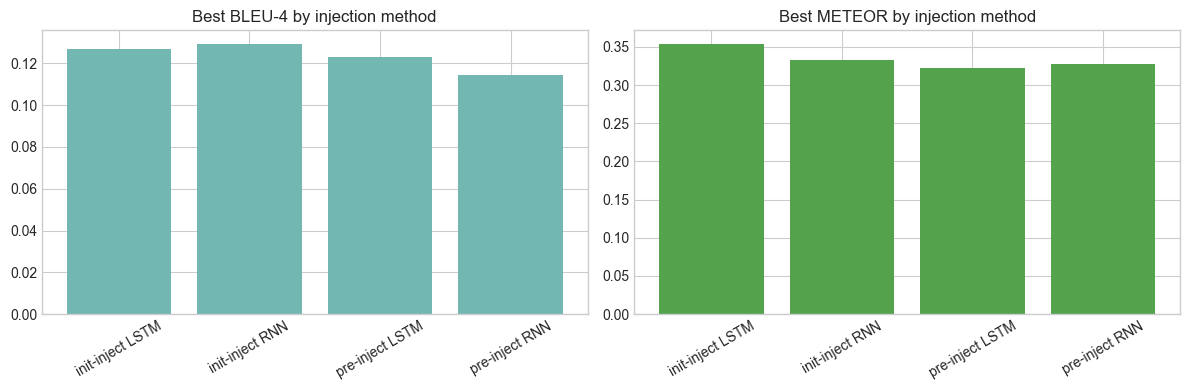

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/preinject_vs_initinject_bonus.png')

In [281]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = inj_summary['injection_method'] + ' ' + inj_summary['model']
axes[0].bar(labels, inj_summary['best_bleu4'], color='#72B7B2')
axes[0].set_title('Best BLEU-4 by injection method')
axes[1].bar(labels, inj_summary['best_meteor'], color='#54A24B')
axes[1].set_title('Best METEOR by injection method')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
path = savefig('preinject_vs_initinject_bonus.png')
plt.show()
path


### Interpretasi Bonus Init-Inject

Pada eksperimen bonus, init-inject menghasilkan skor terbaik keseluruhan yang lebih tinggi dari pre-inject: `initinject_rnn_layers3_hidden128` mencapai BLEU-4 `0.1293`, sedangkan best pre-inject BLEU-4 adalah `0.1230`. Untuk METEOR, init-inject terbaik juga lebih tinggi: `initinject_lstm_layers3_hidden512` mencapai `0.3540`, lebih tinggi dari best pre-inject METEOR `0.3275`.

Hasil ini menunjukkan bahwa, pada konfigurasi eksperimen ini, memasukkan image feature sebagai initial state bisa memberi conditioning awal yang efektif. Namun ini adalah bonus dan perlu dipisahkan dari kesimpulan utama karena spesifikasi utama memakai pre-inject. Selain itu, init-inject RNN terbaik BLEU-4 memiliki waktu `0.0335` detik/gambar, lebih lambat daripada beberapa model utama, sehingga trade-off waktu tetap perlu disebut.


## 13. Bonus: Greedy vs Beam Search

Beam search dievaluasi dari CSV per-image. Karena script lama menyimpan per-image rows tanpa kolom waktu total, tabel ini fokus pada kualitas caption BLEU-4 dan METEOR. Waktu beam search dapat dilaporkan dari log run jika tersedia.

In [282]:
beam_files = [
    FAFO / 'rnn_layers2_hidden128_test_greedy_vs_beam_k3_1000_images.csv',
    FAFO / 'rnn_layers2_hidden128_test_greedy_vs_beam_k5_1000_images.csv',
    FAFO / 'lstm_layers1_hidden128_test_greedy_vs_beam_k3_1000_images.csv',
    FAFO / 'lstm_layers1_hidden128_test_greedy_vs_beam_k5_1000_images.csv',
]
beam_frames = []
for path in beam_files:
    if path.exists():
        df = pd.read_csv(path)
        df['source_file'] = path.name
        beam_frames.append(df)
beam = pd.concat(beam_frames, ignore_index=True) if beam_frames else pd.DataFrame()
beam_summary = beam.groupby(['experiment_id', 'beam_width']).agg(
    images=('image_id', 'count'),
    greedy_bleu4=('greedy_bleu4', 'mean'),
    beam_bleu4=('beam_bleu4', 'mean'),
    greedy_meteor=('greedy_meteor', 'mean'),
    beam_meteor=('beam_meteor', 'mean'),
).reset_index()
beam_summary.round(4)


,experiment_id,beam_width,images,greedy_bleu4,beam_bleu4,greedy_meteor,beam_meteor
0,lstm_layers1_hidden128,3,1000,0.1224,0.1248,0.3216,0.3463
1,lstm_layers1_hidden128,5,1000,0.1224,0.1247,0.3216,0.3488
2,rnn_layers2_hidden128,3,1000,0.1142,0.1136,0.3273,0.3562
3,rnn_layers2_hidden128,5,1000,0.1142,0.1126,0.3273,0.3615


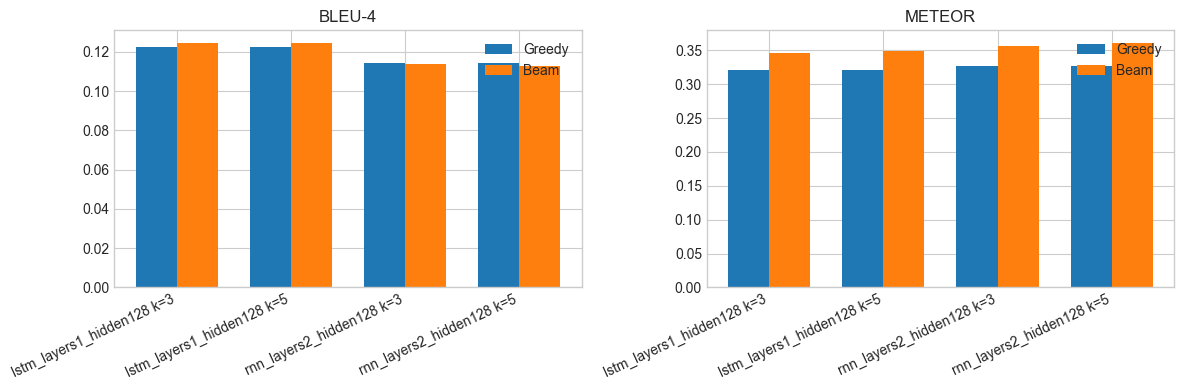

WindowsPath('C:/Fariz/Tugas ITB/ML/Tubes2-ML/artifacts/captioning/report/greedy_vs_beam_bonus.png')

In [283]:
if not beam_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(beam_summary))
    labels = beam_summary['experiment_id'] + ' k=' + beam_summary['beam_width'].astype(str)
    axes[0].bar(x - 0.18, beam_summary['greedy_bleu4'], 0.36, label='Greedy')
    axes[0].bar(x + 0.18, beam_summary['beam_bleu4'], 0.36, label='Beam')
    axes[0].set_title('BLEU-4')
    axes[1].bar(x - 0.18, beam_summary['greedy_meteor'], 0.36, label='Greedy')
    axes[1].bar(x + 0.18, beam_summary['beam_meteor'], 0.36, label='Beam')
    axes[1].set_title('METEOR')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=25, ha='right')
        ax.legend()
    path = savefig('greedy_vs_beam_bonus.png')
    plt.show()
else:
    path = None
path


### Interpretasi Bonus Beam Search

Beam search memperbaiki METEOR pada model terpilih, terutama RNN: METEOR naik dari sekitar `0.3273` greedy menjadi `0.3562` pada beam `k=3` dan `0.3615` pada `k=5`. Untuk LSTM, METEOR juga naik dari sekitar `0.3216` menjadi `0.3463-0.3488`. Namun BLEU-4 tidak selalu naik: LSTM sedikit naik, sedangkan RNN sedikit turun.

Ini menunjukkan beam search memilih caption dengan probabilitas model lebih tinggi, tetapi probabilitas model tidak selalu sejalan dengan BLEU-4. Beam search sering menghasilkan caption lebih panjang atau lebih umum; caption seperti itu dapat meningkatkan overlap unigram/METEOR tetapi menurunkan precision 4-gram BLEU-4. Dengan demikian, beam search membantu sebagian aspek kualitas caption, tetapi bukan jaminan peningkatan semua metrik.


## 14. Temuan Utama

**Model utama pre-inject.** Konfigurasi terbaik berdasarkan BLEU-4 adalah `lstm_layers1_hidden128` dengan BLEU-4 `0.1230`, METEOR `0.3221`, dan waktu inference `0.0245` detik/gambar. Jika metrik utama diganti menjadi METEOR, model terbaik menjadi `rnn_layers2_hidden128` dengan METEOR `0.3275`. Perbedaan ini menunjukkan bahwa pemilihan model tidak hanya bergantung pada satu angka: BLEU-4 lebih ketat terhadap kecocokan urutan 4-gram, sedangkan METEOR lebih toleran terhadap overlap kata dan variasi ekspresi.

**RNN vs LSTM.** RNN terbaik pada eksperimen utama adalah `rnn_layers3_hidden128` dengan BLEU-4 `0.1145`, sedangkan LSTM terbaik adalah `lstm_layers1_hidden128` dengan BLEU-4 `0.1230`. LSTM tetap menjadi pilihan utama jika prioritasnya kualitas n-gram tertinggi, tetapi RNN tidak tertinggal jauh dan bahkan unggul pada konfigurasi tertentu untuk METEOR. Hasil ini masuk akal karena caption Flickr8k relatif pendek; keuntungan LSTM dalam menyimpan dependensi jangka panjang tetap berguna, tetapi tidak selalu menghasilkan margin besar pada semua metrik.

**Keras vs scratch.** Implementasi NumPy scratch menghasilkan exact sentence match `100.00%` untuk RNN dan `100.00%` untuk LSTM pada 500 gambar test yang dievaluasi. Score Keras dan scratch juga identik pada artifact terbaru: RNN BLEU-4 `0.1250/0.1250` dan LSTM BLEU-4 `0.1291/0.1291` untuk Keras/Scratch. Ini menjadi bukti bahwa forward propagation scratch sudah mengikuti bobot dan operasi Keras dengan benar.

**Execution time.** Keras tetap lebih cepat daripada scratch walaupun keduanya berjalan di CPU pada environment ini. Untuk RNN, waktu Keras/Scratch adalah `0.0315/0.0652` detik per gambar; untuk LSTM, `0.0293/0.0769` detik per gambar. Perbedaan ini terutama berasal dari optimasi backend TensorFlow dan batching yang lebih efisien, sedangkan scratch NumPy memakai loop eksplisit agar setiap tahap forward propagation dapat ditelusuri. Karena itu, scratch lebih tepat dibaca sebagai validasi pemahaman dan correctness, bukan sebagai implementasi yang ditargetkan untuk speed.

**Panjang maksimum caption.** Setting panjang caption terbaik pada eksperimen tersimpan adalah `lstm_layers1_hidden128` dengan `max_steps=15` dan BLEU-4 `0.1252`. Hasil ini memperlihatkan bahwa memberi decoder ruang untuk menghasilkan caption lebih panjang tidak otomatis menaikkan kualitas. Setelah inti caption selesai, token tambahan cenderung menambah noise atau kata generik yang menurunkan precision BLEU-4.

**Eksperimen bonus.** Pada alternatif init-inject, BLEU-4 terbaik diperoleh oleh `initinject_rnn_layers3_hidden128` dengan BLEU-4 `0.1293`, sedangkan METEOR terbaik diperoleh oleh `initinject_lstm_layers3_hidden512` dengan METEOR `0.3540`. Hasil bonus ini menunjukkan bahwa cara memasukkan feature gambar ke decoder berpengaruh terhadap kualitas caption, sehingga posisi injection layak dipertimbangkan sebagai desain arsitektur, bukan sekadar detail implementasi.